In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
countries = pd.read_csv('Countries Data.csv')

In [3]:
countries.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     1704 non-null   str    
 1   year        1704 non-null   int64  
 2   population  1704 non-null   int64  
 3   continent   1704 non-null   str    
 4   life_exp    1704 non-null   float64
 5   gdp_cap     1704 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 103.7 KB


In [4]:
countries.head()

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
1,Afghanistan,1957,9240934,Asia,30.332,820.853030
2,Afghanistan,1962,10267083,Asia,31.997,853.100710
3,Afghanistan,1967,11537966,Asia,34.020,836.197138
4,Afghanistan,1972,13079460,Asia,36.088,739.981106


In [5]:
c_52 = countries.loc[countries['year']==1952]
c_52.head()

,country,year,population,continent,life_exp,gdp_cap
0,Afghanistan,1952,8425333,Asia,28.801,779.445314
12,Albania,1952,1282697,Europe,55.230,1601.056136
24,Algeria,1952,9279525,Africa,43.077,2449.008185
36,Angola,1952,4232095,Africa,30.015,3520.610273
48,Argentina,1952,17876956,Americas,62.485,5911.315053


In [6]:
c_07 = countries.loc[countries['year']==2007]
c_07.head()

,country,year,population,continent,life_exp,gdp_cap
11,Afghanistan,2007,31889923,Asia,43.828,974.580338
23,Albania,2007,3600523,Europe,76.423,5937.029526
35,Algeria,2007,33333216,Africa,72.301,6223.367465
47,Angola,2007,12420476,Africa,42.731,4797.231267
59,Argentina,2007,40301927,Americas,75.320,12779.379640


In [7]:
c_merge = c_52.merge(c_07,left_on='country',right_on='country')
c_merge.head()

,country,year_x,population_x,continent_x,life_exp_x,gdp_cap_x,year_y,population_y,continent_y,life_exp_y,gdp_cap_y
0,Afghanistan,1952,8425333,Asia,28.801,779.445314,2007,31889923,Asia,43.828,974.580338
1,Albania,1952,1282697,Europe,55.230,1601.056136,2007,3600523,Europe,76.423,5937.029526
2,Algeria,1952,9279525,Africa,43.077,2449.008185,2007,33333216,Africa,72.301,6223.367465
3,Angola,1952,4232095,Africa,30.015,3520.610273,2007,12420476,Africa,42.731,4797.231267
4,Argentina,1952,17876956,Americas,62.485,5911.315053,2007,40301927,Americas,75.320,12779.379640


In [9]:
df = c_merge.drop(['continent_y','continent_x'],axis=1)
df.head()

,country,year_x,population_x,life_exp_x,gdp_cap_x,year_y,population_y,life_exp_y,gdp_cap_y
0,Afghanistan,1952,8425333,28.801,779.445314,2007,31889923,43.828,974.580338
1,Albania,1952,1282697,55.230,1601.056136,2007,3600523,76.423,5937.029526
2,Algeria,1952,9279525,43.077,2449.008185,2007,33333216,72.301,6223.367465
3,Angola,1952,4232095,30.015,3520.610273,2007,12420476,42.731,4797.231267
4,Argentina,1952,17876956,62.485,5911.315053,2007,40301927,75.320,12779.379640


In [10]:
df['population_growth'] = df['population_y'] - df['population_x']
df.head()

,country,year_x,population_x,life_exp_x,gdp_cap_x,year_y,population_y,life_exp_y,gdp_cap_y,population_growth
0,Afghanistan,1952,8425333,28.801,779.445314,2007,31889923,43.828,974.580338,23464590
1,Albania,1952,1282697,55.230,1601.056136,2007,3600523,76.423,5937.029526,2317826
2,Algeria,1952,9279525,43.077,2449.008185,2007,33333216,72.301,6223.367465,24053691
3,Angola,1952,4232095,30.015,3520.610273,2007,12420476,42.731,4797.231267,8188381
4,Argentina,1952,17876956,62.485,5911.315053,2007,40301927,75.320,12779.379640,22424971


In [13]:
df = df.sort_values('population_growth',ascending=False)
df_top = df.head(10)
df_top.head(10)

,country,year_x,population_x,life_exp_x,gdp_cap_x,year_y,population_y,life_exp_y,gdp_cap_y,population_growth
24,China,1952,556263527,44.000,400.448611,2007,1318683096,72.961,4959.114854,762419569
58,India,1952,372000000,37.373,546.565749,2007,1110396331,64.698,2452.210407,738396331
134,United States,1952,157553000,68.440,13990.482080,2007,301139947,78.242,42951.653090,143586947
59,Indonesia,1952,82052000,37.468,749.681655,2007,223547000,70.650,3540.651564,141495000
14,Brazil,1952,56602560,50.917,2108.944355,2007,190010647,72.390,9065.800825,133408087
97,Pakistan,1952,41346560,43.436,684.597144,2007,169270617,65.483,2605.947580,127924057
8,Bangladesh,1952,46886859,37.484,684.244172,2007,150448339,64.062,1391.253792,103561480
94,Nigeria,1952,33119096,36.324,1077.281856,2007,135031164,46.859,2013.977305,101912068
82,Mexico,1952,30144317,50.789,3478.125529,2007,108700891,76.195,11977.574960,78556574
101,Philippines,1952,22438691,47.752,1272.880995,2007,91077287,71.688,3190.481016,68638596


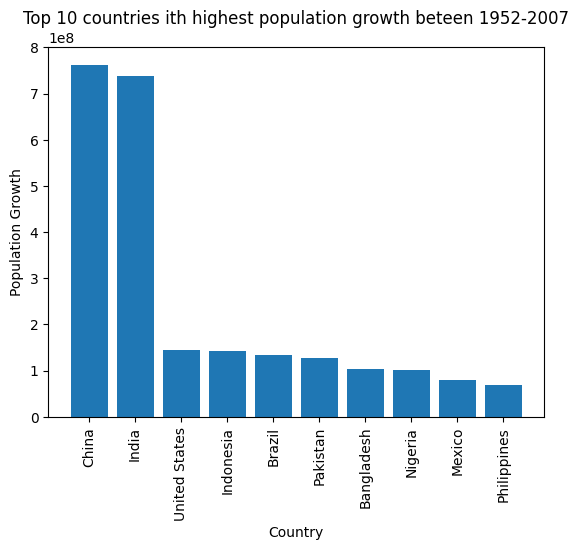

In [14]:
plt.bar(df_top['country'],df_top['population_growth'])
plt.xlabel('Country')
plt.ylabel('Population Growth')
plt.title('Top 10 countries ith highest population growth beteen 1952-2007')
plt.xticks(rotation=90)
plt.show()